# BMI 500 Homework 3 - Python Assessment

## Problems 1 and 2

I used the if/modulo version for Problem 1. The rest are the versions asked for in Problem 2. Since the series sums to $\pi/4$, I multiply the result by 4 when comparing it with $\pi$.

In [1]:
import math
import timeit
import numpy as np
import matplotlib.pyplot as plt


# 2(a) for loop + if/modulo
def leibniz_if(n):
    total = 0.0
    for k in range(n):
        term = 1 / (2 * k + 1)
        if k % 2 == 0:
            total += term
        else:
            total -= term
    return total


# 2(b) for loop + (-1)^k
def leibniz_power(n):
    total = 0.0
    for k in range(n):
        total += (-1) ** k / (2 * k + 1)
    return total


# 2(c) list
def leibniz_list(n):
    terms = [(-1) ** k / (2 * k + 1) for k in range(n)]
    return sum(terms)


# 2(d) set
def leibniz_set(n):
    terms = {(-1) ** k / (2 * k + 1) for k in range(n)}
    return sum(terms)


# 2(e) dictionary
def leibniz_dict(n):
    terms = {k: (-1) ** k / (2 * k + 1) for k in range(n)}
    return sum(terms.values())


# 2(f) NumPy
def leibniz_numpy(n):
    k = np.arange(n)
    return np.sum((-1.0) ** k / (2 * k + 1))


# 2(g) NumPy indexing
def leibniz_numpy_indexed(n):
    x = 1 / (2 * np.arange(n) + 1)
    return np.sum(x[::2]) - np.sum(x[1::2])


# 2(j) pair consecutive terms
def leibniz_paired(n):
    total = 0.0
    for k in range(0, n - 1, 2):
        total += 1 / (2 * k + 1) - 1 / (2 * (k + 1) + 1)
    if n % 2 == 1:
        total += 1 / (2 * (n - 1) + 1)
    return total


implementations = {
    "if/modulo": leibniz_if,
    "power": leibniz_power,
    "list": leibniz_list,
    "set": leibniz_set,
    "dict": leibniz_dict,
    "numpy": leibniz_numpy,
    "numpy indexed": leibniz_numpy_indexed,
    "paired": leibniz_paired,
}

# quick check
for name, fn in implementations.items():
    print(name, fn(5))

Matplotlib is building the font cache; this may take a moment.


if/modulo 0.8349206349206351
power 0.8349206349206351
list 0.834920634920635
set 0.834920634920635
dict 0.834920634920635
numpy 0.8349206349206351
numpy indexed 0.834920634920635
paired 0.8349206349206351


## Problem 3

I used 100,000 terms for the comparison and timed each version three times.

In [2]:
n = 100_000

for name, fn in implementations.items():
    value = fn(n)
    error = abs(4 * value - math.pi)
    seconds = timeit.timeit(lambda: fn(n), number=3) / 3
    print(f"{name:16s} error={error:.2e}  time={seconds:.6f} s")

if/modulo        error=1.00e-05  time=0.009998 s
power            error=1.00e-05  time=0.024075 s


list             error=1.00e-05  time=0.025024 s


set              error=1.00e-05  time=0.033761 s


dict             error=1.00e-05  time=0.028796 s
numpy            error=1.00e-05  time=0.000791 s
numpy indexed    error=1.00e-05  time=0.000155 s
paired           error=1.00e-05  time=0.005727 s


The NumPy versions were clearly the fastest on this run. The errors were all about $10^{-5}$, so there was not much practical difference in accuracy here.

For readability, I prefer the if/modulo version because the alternating sign is obvious. If I needed to use a much larger $n$, I would use NumPy. I would not normally use the set or dictionary versions for this calculation because they add structure that is not really needed.

## Problem 4

I used the if/modulo version for the plot because it is the easiest one for me to read. Both axes are logarithmic. The error keeps going down as $n$ increases, but the convergence is slow.

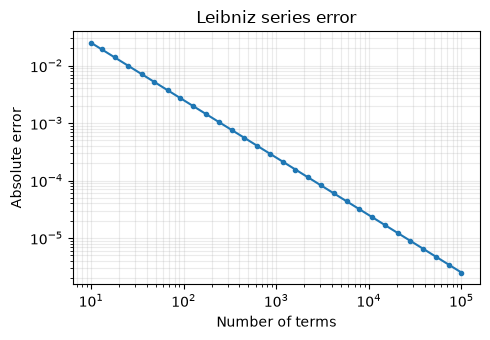

In [3]:
terms = np.unique(np.logspace(1, 5, 30).astype(int))
errors = [abs(leibniz_if(int(n)) - math.pi / 4) for n in terms]

plt.figure(figsize=(5, 3.5))
plt.loglog(terms, errors, marker="o", markersize=3)
plt.xlabel("Number of terms")
plt.ylabel("Absolute error")
plt.title("Leibniz series error")
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.show()